<a href="https://colab.research.google.com/github/MehrabHussain47/Python-Self-Practice/blob/master/Class_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Data Visualization

In [13]:
# Text and Document Visualization
from sklearn.datasets import fetch_20newsgroups # kichu newspaper er data collect korbo
from sklearn.feature_extraction.text import CountVectorizer # Using vectorizer
from wordcloud import WordCloud # Using wordcloud
import matplotlib.pyplot as plt

In [14]:
newsgroups = fetch_20newsgroups(subset='train', categories=['sci.space'])
text = newsgroups.data[:100]

In [15]:
text

["From: henry@zoo.toronto.edu (Henry Spencer)\nSubject: Re: japanese moon landing?\nOrganization: U of Toronto Zoology\nLines: 21\n\nIn article <1qnb9tINN7ff@rave.larc.nasa.gov> C.O.EGALON@LARC.NASA.GOV (CLAUDIO OLIVEIRA EGALON) writes:\n>> there is no such thing as a stable lunar orbit\n>\n>Is it right??? That is new stuff for me. So it means that  you just can \n>not put a sattellite around around the Moon for too long because its \n>orbit will be unstable??? If so, what is the reason??? Is that because \n>the combined gravitacional atraction of the Sun,Moon and Earth \n>that does not provide a stable  orbit around the Moon???\n\nAny lunar satellite needs fuel to do regular orbit corrections, and when\nits fuel runs out it will crash within months.  The orbits of the Apollo\nmotherships changed noticeably during lunar missions lasting only a few\ndays.  It is *possible* that there are stable orbits here and there --\nthe Moon's gravitational field is poorly mapped -- but we know of n

In [16]:
vectorizer = CountVectorizer(stop_words="english", max_features=1000)
x = vectorizer.fit_transform(text)
word_freq = dict(zip(vectorizer.get_feature_names_out(), x.toarray().sum(axis=0)))

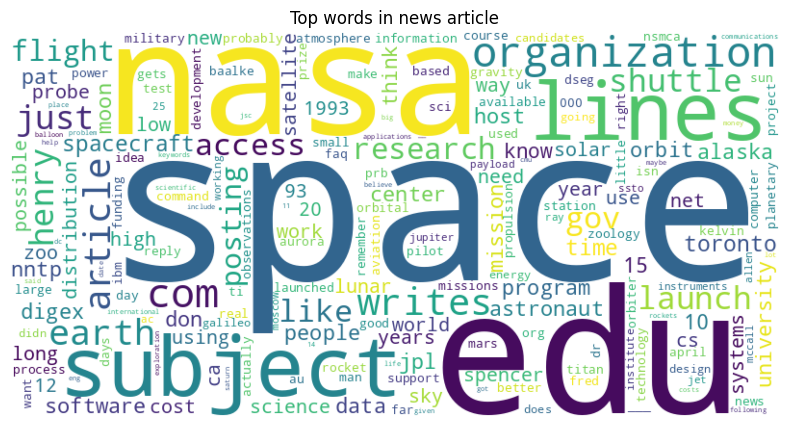

In [19]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="hamming")
plt.axis("off")
plt.title("Top words in news article")
plt.show()

In [20]:
# Multidimensional Data Visualization
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [22]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [23]:
df.shape

(178, 14)

In [24]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(data.data)

In [25]:
tsne_result

array([[ 1.18851328e+01, -4.80538487e-01],
       [ 1.15063944e+01, -1.14784908e+00],
       [ 1.40500355e+01, -1.01552737e+00],
       [ 1.68639297e+01, -1.38428426e+00],
       [ 3.26832032e+00, -4.51541513e-01],
       [ 1.67195301e+01, -1.06726515e+00],
       [ 1.55565186e+01, -8.20219457e-01],
       [ 1.55799885e+01, -1.46961331e+00],
       [ 1.13782101e+01, -1.14926815e+00],
       [ 1.14235554e+01, -5.42934597e-01],
       [ 1.70381622e+01, -1.16640913e+00],
       [ 1.53548336e+01, -7.70621419e-01],
       [ 1.58886137e+01, -9.42175090e-01],
       [ 1.34252825e+01, -9.79047656e-01],
       [ 1.71773663e+01, -1.25744784e+00],
       [ 1.57611694e+01, -1.35757113e+00],
       [ 1.53357754e+01, -1.49119401e+00],
       [ 1.30400639e+01, -9.68884528e-01],
       [ 1.74295769e+01, -1.29208827e+00],
       [ 6.57718372e+00, -6.14467800e-01],
       [ 4.72198772e+00, -4.84827191e-01],
       [ 4.36445856e+00, -2.15410233e-01],
       [ 1.11815300e+01, -5.56922972e-01],
       [ 1.

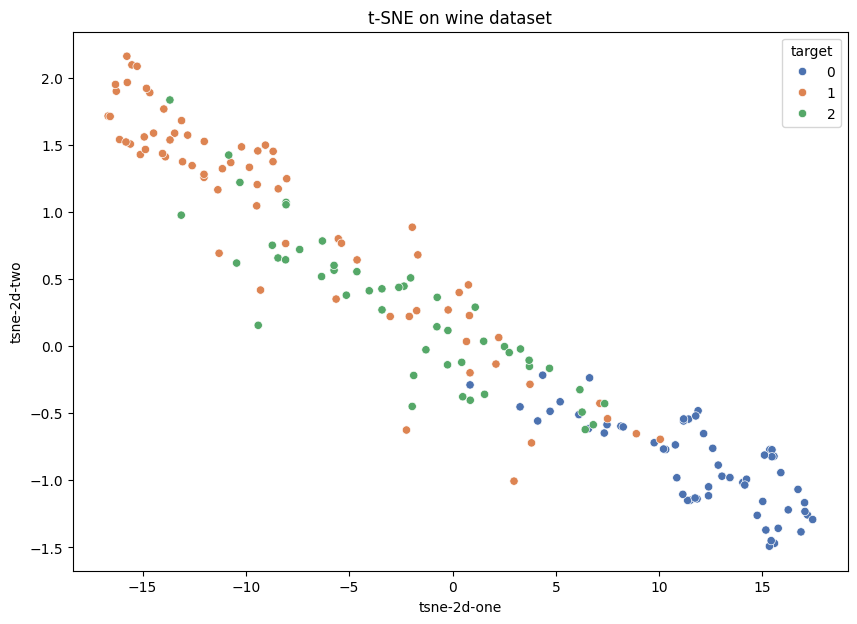

In [26]:
df['tsne-2d-one'] = tsne_result[:, 0]
df['tsne-2d-two'] = tsne_result[:, 1]
plt.figure(figsize=(10, 7))
sns.scatterplot(x='tsne-2d-one', y='tsne-2d-two', hue='target', data=df, palette='deep')
plt.title('t-SNE on wine dataset')
plt.show()

In [27]:
# Comparative Visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = sns.load_dataset('titanic')

In [29]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


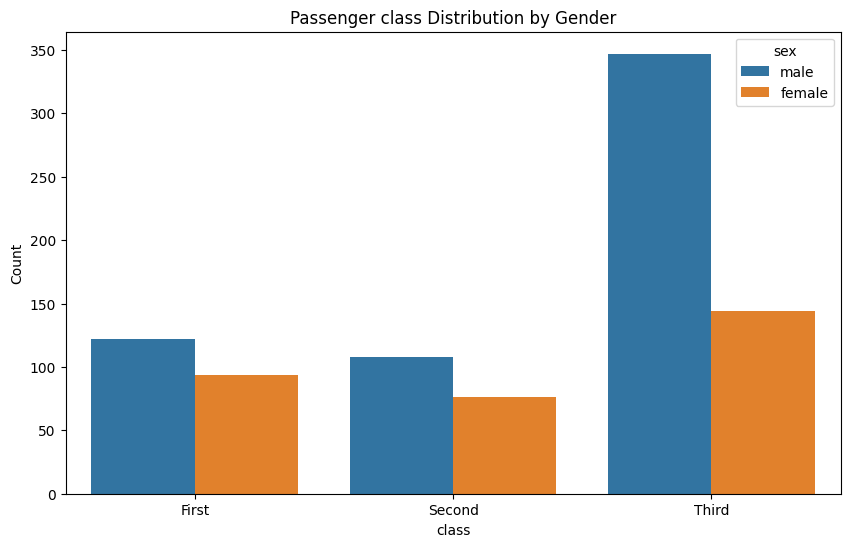

In [31]:
# Compare survival by gender and class

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='class', hue='sex')
plt.title('Passenger class Distribution by Gender')
plt.ylabel('Count')
plt.show()

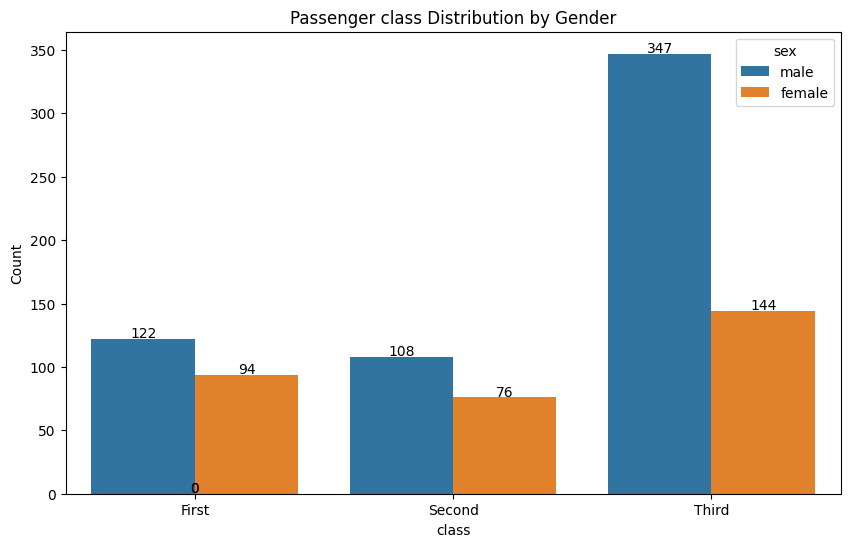

In [34]:
# Compare survival by gender and class with count labels above the bars
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='class', hue='sex')
plt.title('Passenger class Distribution by Gender')
plt.ylabel('Count')
# Add count labels above the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,  # x position
        height + 1,                    # y position (slightly above the bar)
        f'{int(height)}',             # label text
        ha="center"                   # horizontal alignment
    )
plt.show()

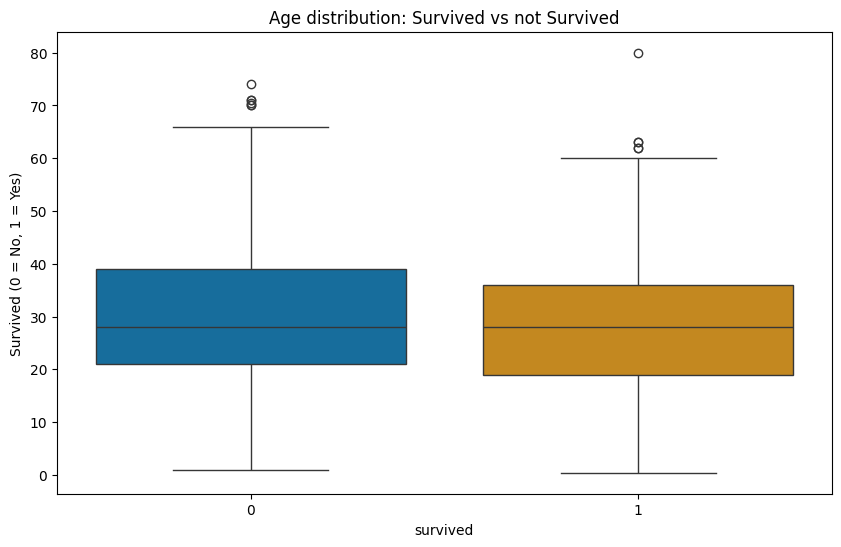

In [52]:
# Age distribution by survival

plt.figure(figsize=(10, 6))
sns.boxplot(x='survived', y='age', data=df, palette='colorblind')
plt.title('Age distribution: Survived vs not Survived')
plt.ylabel('Survived (0 = No, 1 = Yes)')
plt.show()